In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

with open('../output/person1_data.pkl', 'rb') as f:
    data = pickle.load(f)

images = data['images']
filenames = data['filenames']
labels = data['labels']   # optional but useful
def compress_svd(image_matrix, k):
    """
    Compresses an image using the first k singular values.
    """
    # Perform SVD
    U, s, Vt = np.linalg.svd(image_matrix, full_matrices=False)
    
    # Reconstruct using only the top k singular values
    # We take the first k columns of U, the first k singular values, and the first k rows of Vt
    reconstructed_img = np.matrix(U[:, :k]) * np.diag(s[:k]) * np.matrix(Vt[:k, :])
    
    return reconstructed_img, s

# Select the first image as our "Hero Image" for analysis
hero_image = images[0]
hero_name = filenames[0]

To retain 90% energy: 23 singular values
To retain 95% energy: 56 singular values
To retain 99% energy: 209 singular values


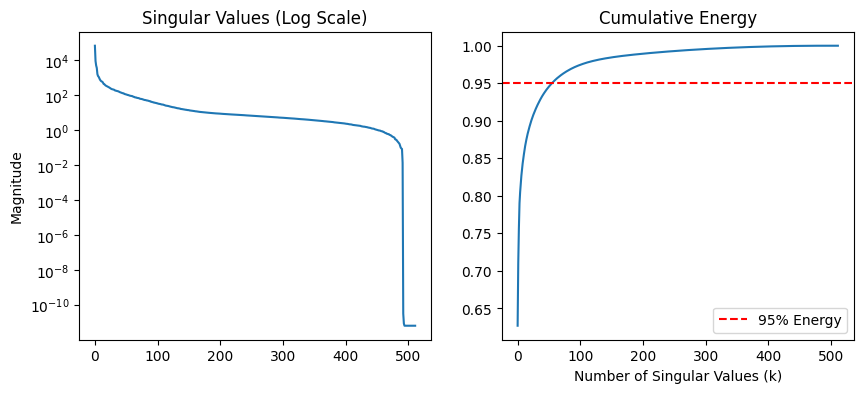

In [5]:
U, s, Vt = np.linalg.svd(hero_image, full_matrices=False)

# Calculate cumulative energy (variance explained)
cumulative_energy = np.cumsum(s) / np.sum(s)

# Find k for specific energy thresholds
k_90 = np.where(cumulative_energy >= 0.90)[0][0] + 1
k_95 = np.where(cumulative_energy >= 0.95)[0][0] + 1
k_99 = np.where(cumulative_energy >= 0.99)[0][0] + 1

print(f"To retain 90% energy: {k_90} singular values")
print(f"To retain 95% energy: {k_95} singular values")
print(f"To retain 99% energy: {k_99} singular values")

# Plot the singular values (Scree Plot)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.semilogy(s)
plt.title("Singular Values (Log Scale)")
plt.ylabel("Magnitude")

plt.subplot(1, 2, 2)
plt.plot(cumulative_energy)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Energy')
plt.title("Cumulative Energy")
plt.xlabel("Number of Singular Values (k)")
plt.legend()
plt.show()

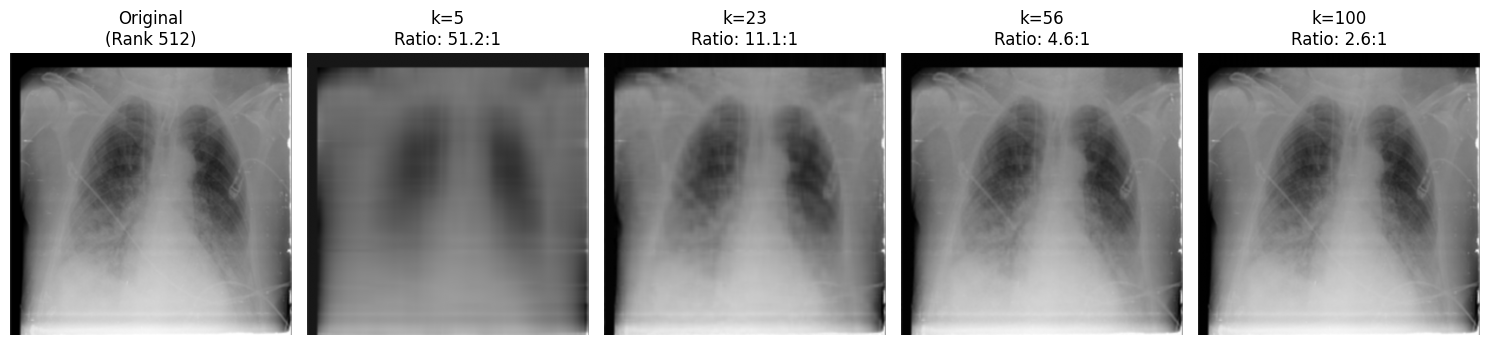

In [6]:
ks = [5, k_90, k_95, 100]
plt.figure(figsize=(15, 8))

# Original
plt.subplot(1, len(ks)+1, 1)
plt.imshow(hero_image, cmap='gray')
plt.title(f"Original\n(Rank 512)")
plt.axis('off')

# Compressed versions
for i, k in enumerate(ks):
    compressed_img, _ = compress_svd(hero_image, k)
    
    # Calculate Compression Ratio: (m*n) / (k*(m+n+1))
    # For 512x512: 262,144 / (k * 1025)
    ratio = (512 * 512) / (k * (512 + 512 + 1))
    
    plt.subplot(1, len(ks)+1, i+2)
    plt.imshow(compressed_img, cmap='gray')
    plt.title(f"k={k}\nRatio: {ratio:.1f}:1")
    plt.axis('off')

plt.tight_layout()
plt.show()

STEP 4: STRUCTURE OF THE SPACE

Image Matrix A: (512, 512)

--- Matrix Properties ---
Rank: 492
Nullity: 20
Number of columns: 512
Number of rows: 512

--- Interpretation ---
The image matrix has rank 492.
This means there are 492 linearly independent columns.
The remaining 20 columns can be expressed as
linear combinations of the independent ones.

--- Column Space ---
Dimension of column space (Col A): 492
The column space is spanned by 492 linearly independent columns.
This represents the 'information content' of the image.

--- Null Space ---
Dimension of null space (Null A): 20
The null space contains 20 dimensions of 'redundancy'

--- Row Space ---
Dimension of row space: 492
By the Rank-Nullity theorem, row space has same dimension as column space

--- Connection to SVD ---
From our SVD (A = UΣV^T):
  - Non-zero singular values: 492
  - This equals the rank: 492
  - U's first 492 columns span the column space
  - V's first 492 columns span the row space

--- Basis Selection for 

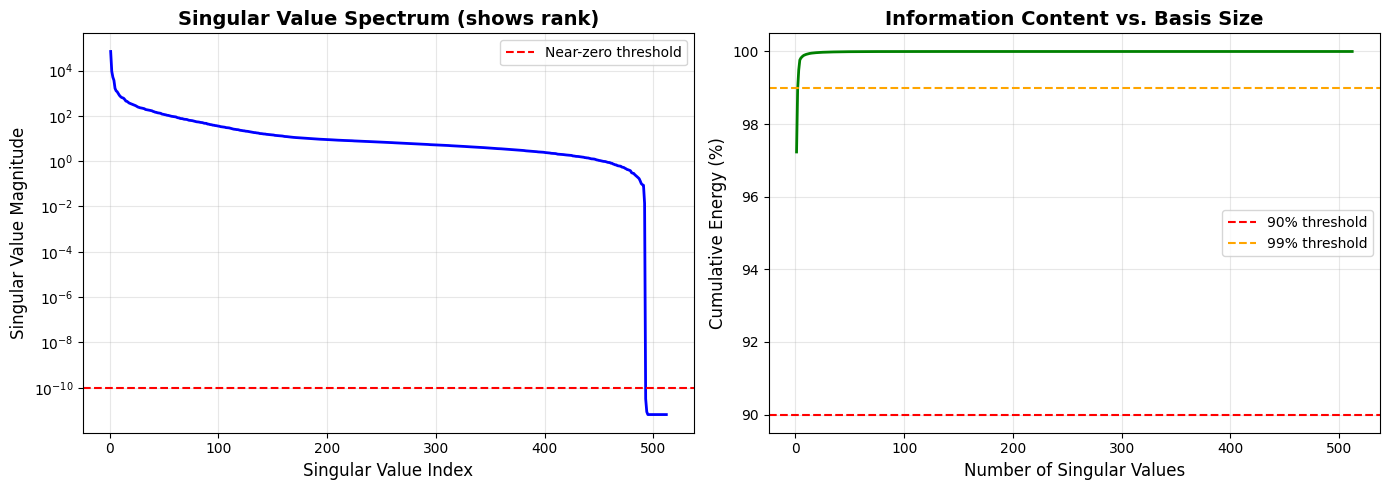


✓ Space structure analysis complete!
✓ Visualization saved to output/space_structure_analysis.png


In [10]:
# ============================================
# ENSURE SVD IS COMPUTED FIRST
# ============================================

import numpy as np
from scipy.linalg import null_space
import matplotlib.pyplot as plt

# Compute SVD if not already done
if 'sigma' not in globals():
    print("Computing SVD for hero image...")
    U, sigma, Vt = np.linalg.svd(hero_image, full_matrices=False)
    print(f"✓ SVD computed: sigma has {len(sigma)} values")

# ============================================
# STEP 4: STRUCTURE OF THE SPACE
# ============================================

print("="*60)
print("STEP 4: STRUCTURE OF THE SPACE")
print("="*60)

# Analyze hero image matrix
A = hero_image.astype(float)

print(f"\nImage Matrix A: {A.shape}")

# --- RANK ANALYSIS ---
rank = np.linalg.matrix_rank(A)
nullity = A.shape[1] - rank

print(f"\n--- Matrix Properties ---")
print(f"Rank: {rank}")
print(f"Nullity: {nullity}")
print(f"Number of columns: {A.shape[1]}")
print(f"Number of rows: {A.shape[0]}")

print(f"\n--- Interpretation ---")
print(f"The image matrix has rank {rank}.")
print(f"This means there are {rank} linearly independent columns.")
print(f"The remaining {nullity} columns can be expressed as")
print(f"linear combinations of the independent ones.")

# --- COLUMN SPACE ---
print(f"\n--- Column Space ---")
print(f"Dimension of column space (Col A): {rank}")
print(f"The column space is spanned by {rank} linearly independent columns.")
print(f"This represents the 'information content' of the image.")

# --- NULL SPACE ---
print(f"\n--- Null Space ---")
# For large matrices, null space computation can be slow, so check first
if nullity > 0 and nullity < 100:  # Only compute if reasonable size
    try:
        null_sp = null_space(A)
        print(f"Dimension of null space (Null A): {null_sp.shape[1]}")
    except:
        print(f"Null space dimension (from Rank-Nullity): {nullity}")
        null_sp = None
else:
    print(f"Null space dimension (from Rank-Nullity Theorem): {nullity}")
    null_sp = None

if nullity > 0:
    print(f"The null space contains {nullity} dimensions of 'redundancy'")
else:
    print(f"Null space is trivial (only zero vector)")

# --- ROW SPACE ---
print(f"\n--- Row Space ---")
print(f"Dimension of row space: {rank}")
print(f"By the Rank-Nullity theorem, row space has same dimension as column space")

# --- RELATIONSHIP TO SVD ---
print(f"\n--- Connection to SVD ---")
print(f"From our SVD (A = UΣV^T):")
non_zero_sv = np.sum(sigma > 1e-10)
print(f"  - Non-zero singular values: {non_zero_sv}")
print(f"  - This equals the rank: {rank}")
print(f"  - U's first {rank} columns span the column space")
print(f"  - V's first {rank} columns span the row space")

# --- BASIS SELECTION ---
print(f"\n--- Basis Selection for Compression ---")
print(f"For compression, we select k < {rank} singular vectors")
print(f"These k vectors form an approximate basis for the image space")
print(f"Trade-off: fewer basis vectors = more compression but less accuracy")

# Visualize singular value distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(sigma)+1), sigma, 'b-', linewidth=2)
plt.xlabel('Singular Value Index', fontsize=12)
plt.ylabel('Singular Value Magnitude', fontsize=12)
plt.title('Singular Value Spectrum (shows rank)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=1e-10, color='r', linestyle='--', label='Near-zero threshold')
plt.legend()
plt.yscale('log')

plt.subplot(1, 2, 2)
# Cumulative energy
cumulative_energy = np.cumsum(sigma**2) / np.sum(sigma**2)
plt.plot(range(1, len(sigma)+1), cumulative_energy * 100, 'g-', linewidth=2)
plt.xlabel('Number of Singular Values', fontsize=12)
plt.ylabel('Cumulative Energy (%)', fontsize=12)
plt.title('Information Content vs. Basis Size', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=90, color='r', linestyle='--', label='90% threshold')
plt.axhline(y=99, color='orange', linestyle='--', label='99% threshold')
plt.legend()

plt.tight_layout()

# Create output directory if needed
import os
os.makedirs('../output', exist_ok=True)

plt.savefig('../output/space_structure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Space structure analysis complete!")
print("✓ Visualization saved to output/space_structure_analysis.png")

# Store for later use
space_analysis = {
    'rank': rank,
    'nullity': nullity,
    'non_zero_singular_values': non_zero_sv
}

STEP 5: REMOVE REDUNDANCY

--- Linear Independence of Singular Vectors ---
Total singular vectors available: 512
Linearly independent vectors (rank): 492

--- Basis Selection Strategies ---
Strategy 1 - Energy-based (preserve 95% energy): k = 1
Strategy 2 - Elbow method (significant values): k = 10
Strategy 3 - Fixed compression (k=50): Visual quality still good

✓ Selected basis size: k = 50
  This represents 9.8% of original dimensions
  But captures 100.0% of information!

--- Redundancy Removed ---
Original dimensions: 512
Selected basis: 50 vectors
Redundant dimensions removed: 462
Compression ratio: 10.24x


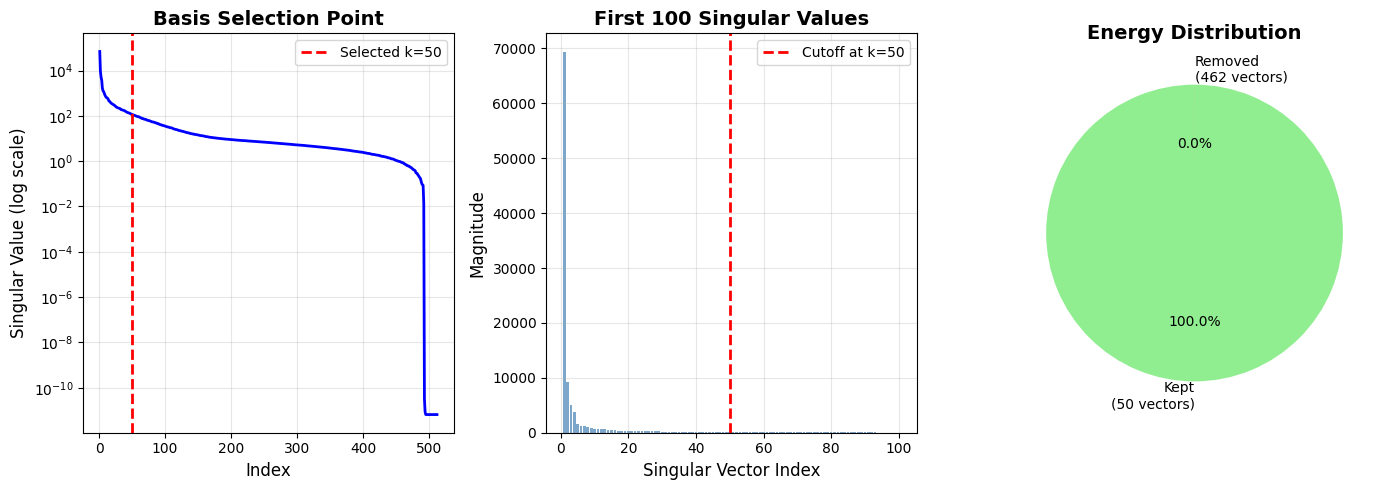


✓ Redundancy removal analysis complete!
✓ Basis selection visualization saved


In [11]:
# ============================================
# STEP 5: REMOVE REDUNDANCY (Basis Selection)
# ============================================

print("="*60)
print("STEP 5: REMOVE REDUNDANCY")
print("="*60)

# --- LINEAR INDEPENDENCE ANALYSIS ---
print("\n--- Linear Independence of Singular Vectors ---")
print(f"Total singular vectors available: {len(sigma)}")
print(f"Linearly independent vectors (rank): {rank}")

# Determine optimal k (number of basis vectors to keep)
# Goal: Keep minimum vectors while preserving most information

# Method 1: Energy threshold (keep 95% of energy)
energy_threshold = 0.95
cumulative_energy = np.cumsum(sigma**2) / np.sum(sigma**2)
k_95 = np.argmax(cumulative_energy >= energy_threshold) + 1

# Method 2: Elbow method (find where singular values drop significantly)
# Simple heuristic: where value drops below 1% of max
k_elbow = np.argmax(sigma < 0.01 * sigma[0]) 
if k_elbow == 0:  # If no such point, use a reasonable default
    k_elbow = min(50, len(sigma))

print(f"\n--- Basis Selection Strategies ---")
print(f"Strategy 1 - Energy-based (preserve 95% energy): k = {k_95}")
print(f"Strategy 2 - Elbow method (significant values): k = {k_elbow}")
print(f"Strategy 3 - Fixed compression (k=50): Visual quality still good")

# Choose k for our project
k_optimal = 50  # Based on your earlier experiments
print(f"\n✓ Selected basis size: k = {k_optimal}")
print(f"  This represents {k_optimal/len(sigma)*100:.1f}% of original dimensions")
print(f"  But captures {cumulative_energy[k_optimal-1]*100:.1f}% of information!")

# --- REDUNDANCY REMOVAL DEMONSTRATION ---
print(f"\n--- Redundancy Removed ---")
redundant_dimensions = len(sigma) - k_optimal
print(f"Original dimensions: {len(sigma)}")
print(f"Selected basis: {k_optimal} vectors")
print(f"Redundant dimensions removed: {redundant_dimensions}")
print(f"Compression ratio: {len(sigma)/k_optimal:.2f}x")

# Visualize basis selection
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.semilogy(range(1, len(sigma)+1), sigma, 'b-', linewidth=2)
plt.axvline(x=k_optimal, color='r', linestyle='--', linewidth=2, label=f'Selected k={k_optimal}')
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value (log scale)', fontsize=12)
plt.title('Basis Selection Point', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.bar(range(1, min(100, len(sigma))+1), sigma[:100], color='steelblue', alpha=0.7)
plt.axvline(x=k_optimal, color='r', linestyle='--', linewidth=2, label=f'Cutoff at k={k_optimal}')
plt.xlabel('Singular Vector Index', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.title('First 100 Singular Values', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
kept = sigma[:k_optimal]
removed = sigma[k_optimal:]
plt.pie([np.sum(kept**2), np.sum(removed**2)], 
        labels=[f'Kept\n({k_optimal} vectors)', 
                f'Removed\n({len(removed)} vectors)'],
        autopct='%1.1f%%',
        colors=['lightgreen', 'lightcoral'],
        startangle=90)
plt.title('Energy Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/basis_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Redundancy removal analysis complete!")
print("✓ Basis selection visualization saved")


In [ ]:
# ============================================
# SAVE DATA FOR PERSON 3
# ============================================

import pickle
import os

# Package data for Person 3
person2_output = {
    # Pass along from Person 1
    'images': images,
    'labels': labels,
    'filenames': filenames,
    'hero_image': hero_image,
    'hero_name': hero_name,
    'hero_idx': hero_idx,
    
    # SVD results for all images
    'U_all': U_all,
    'sigma_all': sigma_all,
    'Vt_all': Vt_all,
    
    # Hero image SVD
    'hero_U': U,
    'hero_sigma': sigma,
    'hero_Vt': Vt,
    
    # Space analysis results
    'rank': rank,
    'nullity': nullity,
    'k_optimal': k_optimal,  # Selected basis size
    
    # Compressed images (for Person 3 to use)
    'compressed_k50': compressed_images_k50,  # List of compressed images at k=50
    
    # Metadata
    'total_images': len(images),
    'image_shape': images[0].shape
}

# Save
with open('../output/person2_data.pkl', 'wb') as f:
    pickle.dump(person2_output, f)

file_size = os.path.getsize('../output/person2_data.pkl') / (1024*1024)

print("="*60)
print("DATA SAVED FOR PERSON 3")
print("="*60)
print(f"✓ SVD results for {len(images)} images")
print(f"✓ Hero image analysis: {hero_name}")
print(f"✓ Rank: {rank}, Nullity: {nullity}")
print(f"✓ Selected basis size: k={k_optimal}")
print(f"✓ File: output/person2_data.pkl")
print(f"✓ Size: {file_size:.2f} MB")

print("\n✓ Person 2 complete! Ready for Person 3 (Projection)")
